In [1]:
#bias correction: statisctical post processing

#what is done? predict the difference between station observations of 2m-temp and 
#- the corresponding forecast prediction at the nearest gridpoint to the observation location.
#this is done to correct for the errors.

In [2]:
#RANDOM FOREST

In [3]:
import numpy as np
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
#load data: predict the forecast_error
base_url = "https://object-store.os-api.cci1.ecmwf.int/sop/"

forecast_error = np.genfromtxt(base_url + "forecast_error.csv", delimiter=",", skip_header=1)
#load in variables one at a time(.reshape() puts in correct format for later)
soil_temperature = np.genfromtxt(base_url + "soil_temperature.csv", delimiter=",", skip_header=1).reshape(-1, 1)
time_of_day = np.genfromtxt(base_url + "time_of_day.csv", delimiter=",", skip_header=1).reshape(-1, 1)

In [ ]:
#load data: predict the forecast_error
path = '.../ECMWF/object-store.os-api.cci1.ecmwf.int/sop/'

forecast_error = np.genfromtxt(path + "forecast_error.csv", delimiter=",", skip_header=1)
#load in variables one at a time(.reshape() puts in correct format for later)
soil_temperature = np.genfromtxt(path + "soil_temperature.csv", delimiter=",", skip_header=1).reshape(-1, 1)
time_of_day = np.genfromtxt(path + "time_of_day.csv", delimiter=",", skip_header=1).reshape(-1, 1)

In [5]:
print('Forecast error shape:', forecast_error.shape) #to predict
print('Soil temperature shape:', soil_temperature.shape)
print('Time of day shape:', time_of_day.shape)

Forecast error shape: (5265488,)
Soil temperature shape: (5265488, 1)
Time of day shape: (5265488, 1)


In [6]:
#in the above data,  stations with inconsistent measurement locations, 
#- repeated values, or even physically invalid numbers are removed

In [7]:
#split data: 80% in trainig set and 20% in testing set
#not creating validation set because hyperparameter space is not explored
#splitting data ideally requires geospatial location and time but a random sampling is done here!

In [8]:
(forecast_error_train, forecast_error_test, time_of_day_train, time_of_day_test,
soil_temperature_train,  soil_temperature_test) = train_test_split(forecast_error, #the variables to split
                                                                    time_of_day,
                                                                    soil_temperature,
                                                                    test_size = 0.2, #proportion of data to use in the test set i.e., predictors
                                                                    random_state = 40, #set the random seed for reproducibility
                                                                      )

In [9]:
#model univariate regression of the forecast_error only on the time_of_day
#also define some hyperparameters like the number of trees in the random forest, and the maximum depth of any single tree

In [10]:
#Random Forest likes a 1D vector to predict.
X = time_of_day_train #input
Y = forecast_error_train #output

#Create the Random Forest regression object
regress = RandomForestRegressor(n_estimators = 8, #number of trees in the forest
                            max_depth = 6, #maximum depth any tree is allowed to have
                            )

#train the model
regress.fit(X, Y)

,n_estimators,8
,criterion,'squared_error'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [11]:
#evaluate the model using root-mean-squared error (RMSE) and mean-absolute error (MAE)
#the baseline is no error correction, or a correction of 0.

In [12]:
zero_test = 0.0 * forecast_error_test

#MAE
baseline_mae = metrics.mean_absolute_error(zero_test, forecast_error_test)
#RMSE
baseline_rmse = np.sqrt(metrics.mean_squared_error(zero_test, forecast_error_test))

In [13]:
#baseline error metrics
print('Mean Absolute Error Uncorrected:', baseline_mae)
print('Root Mean Squared Error Uncorrected:', baseline_rmse)

Mean Absolute Error Uncorrected: 1.6349125826461286
Root Mean Squared Error Uncorrected: 2.2578143996125855


In [14]:
#generate error predictions at the times of day used in the test data

X_test = time_of_day_test

forecast_corrected = regress.predict(X_test)

corrected_mae = metrics.mean_absolute_error(forecast_error_test, forecast_corrected)
corrected_rmse = np.sqrt(metrics.mean_squared_error(forecast_error_test, forecast_corrected))

In [15]:
#print the corrected forecast error and 
#percentage improvement in corrected forecast error, compared to the baseline forecast error

In [16]:
print(' Corrected Mean Absolute Error:', corrected_mae)
print(' Corrected Root Mean Squared Error:', corrected_rmse)

print('% Improvement MAE: ', (baseline_mae - corrected_mae)/baseline_mae * 100 )
print('% Improvement RMSE: ', (baseline_rmse - corrected_rmse)/baseline_rmse * 100 )

 Corrected Mean Absolute Error: 1.5810383325718038
 Corrected Root Mean Squared Error: 2.20140954034496
% Improvement MAE:  3.2952373506801544
% Improvement RMSE:  2.4982061978745476


In [17]:
#the corrected MAE and RMSE should be lower than the uncorrected/baseline MAE and RMSE
#plot the model error predictions and the observed predictions from the test set against time of day

In [18]:
time_of_day_test[:,0]

array([13.79533386, 18.31800079,  8.27799988, ...,  4.14533234,
       15.19533539, 12.63600159], shape=(1053098,))

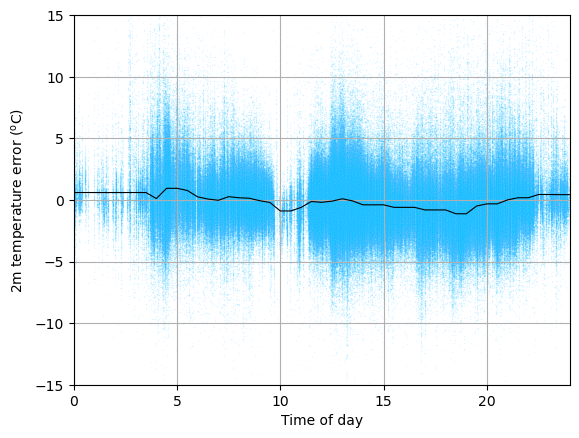

In [19]:
#predict the outputs for all values between 0 & 24 (time of day).
x = np.linspace(0, 24, 49)[...,np.newaxis] #each half hour
y = regress.predict(x)

#graph of the time of day against the forecast error. (make x and y 1D)
sns.scatterplot(x= time_of_day_test[:,0], y = forecast_error_test.reshape(-1, 1)[:,0] , 
               s = 1, alpha=0.1, color= 'deepskyblue')

#plot the number of measurements at each time of day and forecast error
plt.xlim([0, 24])
plt.ylim([-15, 15])
plt.grid()
plt.xlabel('Time of day')
plt.ylabel(r'2m temperature error ($^\mathrm{o}$C)')

#Line of best fit
plt.plot(x,y,'black', linewidth= 0.8)

In [20]:
#at a given time of the day, there are large range of possible errors
#add another predictor = soil_temperature and train the model

In [21]:
#concatenate predictors into a single array
X_2pred = np.concatenate([time_of_day_train, soil_temperature_train], axis=-1)

#target is still the forecast error and train
Y_2pred = forecast_error_train

reg = RandomForestRegressor(n_estimators = 8, max_depth = 6)
reg.fit(X_2pred, Y_2pred)

,n_estimators,8
,criterion,'squared_error'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [22]:
#generate error predictions at the times of day used in the test data

X_2pred_test = np.concatenate([time_of_day_test, soil_temperature_test], axis=-1)
forecast_2pred_corrected = reg.predict(X_2pred_test)

corrected_mae_2pred = metrics.mean_absolute_error(forecast_error_test, forecast_2pred_corrected)
corrected_rmse_2pred = np.sqrt(metrics.mean_squared_error(forecast_error_test, forecast_2pred_corrected))

print('2predictors- Corrected Mean Absolute Error:', corrected_mae_2pred)
print('2predictors- Corrected Root Mean Squared Error:', corrected_rmse_2pred)

print('% Improvement MAE (2predictors): ', (baseline_mae - corrected_mae_2pred)/baseline_mae * 100 )
print('% Improvement RMSE (2predictors): ', (baseline_rmse - corrected_rmse_2pred)/baseline_rmse * 100 )

2predictors- Corrected Mean Absolute Error: 1.5597455089637162
2predictors- Corrected Root Mean Squared Error: 2.1630649216831612
% Improvement MAE (2predictors):  4.597620354768658
% Improvement RMSE (2predictors):  4.196513138798394


In [23]:
#with more predictors, better improvement i.e., more than 4% for both MAE and RMSE when compared to before